In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 支持中文
matplotlib.rcParams['axes.unicode_minus'] = False  # 正常显示负号

### **0.读取数据并获得基本信息**

In [17]:
data = pd.read_csv('科技创新能力评价数据.csv')
data.set_index('地区', inplace = True)

regions = data.index.tolist()
columns = data.columns.tolist()
X_raw = data.values.astype(np.float64)
m, n = X_raw.shape
print(f'方案数m：{m}, 指标数n：{n}')

方案数m：10, 指标数n：7


### **1.指标正向化**

#### 1.1成本型数据（GDP能耗）
x = max(x) - x

In [18]:
#深拷贝
X_pos = X_raw.copy()
col_cost = 2

X_pos[:, col_cost] = np.max(X_pos[:, col_cost], axis = 0) - X_pos[:, col_cost]
X_pos[:, col_cost]

array([0.16, 0.23, 0.  , 0.17, 0.21, 0.19, 0.03, 0.15, 0.22, 0.18])

#### 1.2中间型数据（科技成果转化率）
$$
x = 1 - \frac{|x - x_{\text{best}}|}{\max_{i} |x_i - x_{\text{best}}|}
$$

In [19]:
col_mid = 5
x_best = 60
deviations = np.abs(X_pos[:, col_mid] - x_best)
max_dev = np.max(deviations, axis = 0)
#规避除零风险
if max_dev == 0:
    max_dev = 1

X_pos[:, col_mid] = 1 - deviations / max_dev
X_pos[:, col_mid]

array([0.66666667, 0.86666667, 0.6       , 0.        , 1.        ,
       0.86666667, 0.33333333, 0.8       , 0.93333333, 0.93333333])

#### 1.3区间型数据（政策支持强度）
若最佳区间为[a, b]
| 标准 | 结果 |
|---|---|
| `x < a` | x = 1 - (a - x) / max(a - min(x), max(x) - b)    |
| `a < x < b` | x = 1       |
| `x > b` | x = 1 - (x - b) / max(a - min(x), max(x) - b)   |

In [20]:
col_interval = 6
a, b = 70, 90
vals = X_pos[:, col_interval]

M = max(a - np.min(vals, axis = 0),
        np.max(vals, axis = 0) - b)
if M == 0:
    M = 1
new_vals = np.ones(vals.shape)

for i in range(m):
    if vals[i] < a:
        new_vals[i] = 1 - (a - vals[i]) / M
    elif vals[i] > b:
        new_vals[i] = 1 - (vals[i] - b) / M
X_pos[:, col_interval] = new_vals
X_pos[:, col_interval]

array([1. , 1. , 0.5, 0. , 1. , 1. , 1. , 1. , 0.5, 1. ])

### **2.标准化（平方与归一化）**
$$z_{ij} = \frac{x_{ij}}{\sqrt{\sum_{i} x_{ij}^2}}$$

In [21]:
norm = X_pos / np.sqrt(np.sum(X_pos ** 2, axis = 0))
pd.DataFrame(X_pos, index = regions, columns = columns)     #前面已经将 index 和 columns 的标签裁去了，为直观，这里加回来

,经费,研发人员,GDP能耗,高企数量,专利数,科技成果转化率,政策支持强度
A省,2.8,165.0,0.16,1020.0,2300.0,0.666667,1.0
B省,3.5,120.0,0.23,890.0,1950.0,0.866667,1.0
C省,2.2,140.0,0.00,1100.0,2500.0,0.600000,0.5
D省,3.1,155.0,0.17,980.0,2100.0,0.000000,0.0
E省,2.5,180.0,0.21,950.0,2400.0,1.000000,1.0
F省,3.3,170.0,0.19,1050.0,2350.0,0.866667,1.0
G省,2.9,130.0,0.03,970.0,2000.0,0.333333,1.0
H省,2.6,160.0,0.15,930.0,2250.0,0.800000,1.0
I省,3.0,150.0,0.22,1000.0,2150.0,0.933333,0.5
J省,2.4,145.0,0.18,960.0,2050.0,0.933333,1.0


### **3.配权重（熵权法）**
> 当然，暂时不会熵权法也可以直接让各属性平均分配权重

#### 3.1 先做 min-max 归一化（熵权法要求数据非负且同向）

In [22]:
norm_mm = (norm - norm.min(axis=0)) / (norm.max(axis=0) - norm.min(axis=0))
# 防止出现 0（log(0) = -inf）
norm_mm = np.clip(norm_mm, 1e-10, 1)

#### 3.2 计算每个指标的信息熵
$$
P_{ij} = \frac{\text{norm\_mm}_{ij}}{\sum_{k,l} \text{norm\_mm}_{kl}}
$$
以及
$$
e_j = -k \sum_{i} P_{ij} \ln(P_{ij}), \quad k = \frac{1}{\ln(m)}
$$

In [23]:
P = norm_mm / norm_mm.sum(axis=0)

k = 1 / np.log(m)
entropy = -k * np.sum(P * np.log(P), axis=0)   # 每个指标的信息熵

#### 3.3 熵权：差异系数 / 总差异系数

In [24]:
diff_coeff = 1 - entropy                       # 信息效用值（差异系数）
weights = diff_coeff / diff_coeff.sum()        # 归一化得到权重
weights

array([0.16897503, 0.14467337, 0.12806625, 0.15525425, 0.2019394 ,
       0.10275198, 0.09833972])

### **4.Topsis计算**

#### 4.1加权标准化矩阵

In [25]:
weighted = norm * weights

#### 4.2正理想解与负理想解

In [26]:
#各属性的最大值
Z_plus = np.max(weighted, axis = 0)
#各属性的最小值
Z_minus = np.min(weighted, axis = 0)

#### 4.3各对象到理想解的距离（欧几里得距离）
$$D_{+, i} = \sqrt{\sum_{j} \left( W_{ij} - Z_{+, j} \right)^2}$$

In [27]:
#与正理想解的距离
D_plus = np.sqrt(np.sum((weighted - Z_plus) ** 2, axis = 1))
#与负理想解的距离
D_minus = np.sqrt(np.sum((weighted - Z_minus) ** 2, axis = 1))

#### 4.4计算综合得分
$$score = \frac{D_{-}}{D_{+} + D_{-}}$$

In [28]:
scores = D_minus / (D_plus + D_minus)

max_score, index = np.max(scores), np.argmax(scores)
print(max_score.round(4), regions[int(index)])

0.8507 F省


#### 4.5据得分排名

In [52]:
sorted_index = scores.argsort()[:: -1]
rank = sorted_index.argsort() + 1
sorted_regions = np.array(regions)[sorted_index]
sorted_scores = scores[sorted_index]
sorted_regions

array(['F省', 'E省', 'B省', 'I省', 'A省', 'J省', 'H省', 'D省', 'G省', 'C省'],
      dtype='<U2')

### **5.绘图**

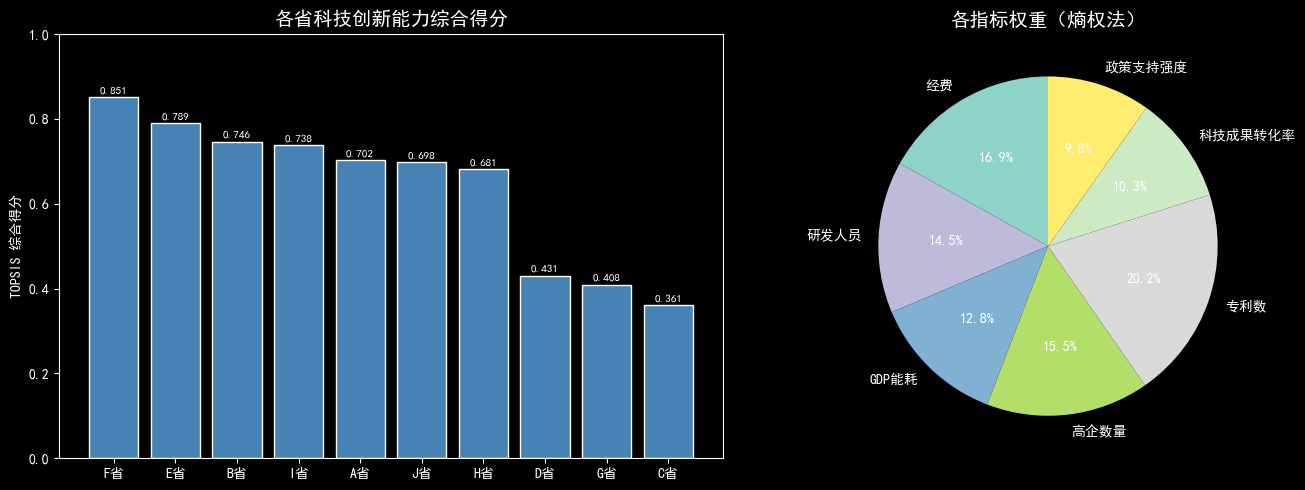


结果图已保存为 topsis_result.png


In [31]:
#实际上，整体的绘图代码在不同项目中可以直接复制粘贴，只需要修改关于几个特定项目的数据变量就行
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：得分柱状图（按省份排序）
axes[0].bar(sorted_regions, sorted_scores, color='steelblue', edgecolor='white')
axes[0].set_title('各省科技创新能力综合得分', fontsize=14)
axes[0].set_ylabel('TOPSIS 综合得分')
axes[0].set_ylim(0, 1)
for i, (r, s) in enumerate(zip(sorted_regions, sorted_scores)):
    axes[0].text(i, s + 0.01, f'{s:.3f}', ha='center', fontsize=8)

# 右图：权重饼图
axes[1].pie(
    weights, labels=columns, autopct='%1.1f%%',
    colors=plt.cm.Set3(np.linspace(0, 1, 7)),
    startangle=90
)
axes[1].set_title('各指标权重（熵权法）', fontsize=14)

plt.tight_layout()
plt.savefig('topsis_result.png', dpi=200)
plt.show()
print("\n结果图已保存为 topsis_result.png")

### **6.稳定性分析（非必要）**
 将权重微调百分之五（根据实际情况可对数值进行调整）占比看看排名的变化情况

#### 6.1计算稳定性

In [49]:
stable_count = np.zeros(m)

for col_index in range(n):
    for delta in [-0.05, 0.05]:
        #微调权重（自行根据实际情况来设定其取值）
        w_test = weights.copy()
        w_test[col_index] += delta
        w_test = np.clip(w_test, 0.01, None)
        w_test /= w_test.sum()

        #重新计算Topsis
        weighted_test = w_test * norm
        Z_p = np.max(weighted_test, axis = 0)
        Z_m = np.min(weighted_test, axis = 0)
        D_p = np.sqrt(np.sum((weighted_test - Z_p) ** 2, axis = 1))
        D_m = np.sqrt(np.sum((weighted_test - Z_m) ** 2, axis = 1))
        scores_test = D_m / (D_p + D_m)

        #看排名变化情况
        rank_test = scores_test.argsort()[:: -1].argsort() + 1
        stable_count += (rank_test == rank)
stability = stable_count / (2 * n)

#### 6.2保存结果

In [50]:
evaluation = []
for rate in stability:
    if rate >= 0.8:
        evaluation.append("高度稳定")
    elif rate >= 0.5:
        evaluation.append("较稳定")
    else:
        evaluation.append("不稳定")

df = pd.DataFrame({
    '地区' : regions,
    '排名' : rank,
    '稳定性' : stability,
    '评价' : evaluation
})

df.to_csv('各省排名稳定性分析.csv', index = False, encoding = 'utf-8')
print("各省排名的稳定性状况已保存为'各省排名稳定性分析.csv'")

各省排名的稳定性状况已保存为'各省排名稳定性分析.csv'
